# Underwear-Index -- can men's underwear sales call a recession?
### The Greenspan 'Men's Underwear Index', tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Here is a piece of macro folklore attributed to **Alan Greenspan**: men treat underwear as a near-necessity and replace it on a steady schedule, so when household budgets get squeezed, men's-underwear sales quietly *dip* -- supposedly an early warning of a recession. This notebook asks the only question that matters: does the dip actually **lead** a downturn, or is it just a coincident description of bad times we already know about?

> **This is the plain-language layer.** Want the Fisher exact test, the permutation distribution, the HAC t-stat and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Honesty note up front.** There is no clean public long-run series for this niche category, so the underwear index here is a *curated reconstruction* (a smooth trend with stylised recession dips). The recession calendar (NBER) and the S&P 500 tape (Shiller) are real. So the *predictor's raw series is stylised* -- which we flag loudly -- but the test against real recessions and real markets is genuine.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from underwear_index import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("Shiller cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=33, n_dips=4, year_start=1992, year_end=2024,
    uncond_rec_pct=15.2, rec_rate_dip_pct=25.0, rec_rate_nodip_pct=13.8,
    next_fisher_p=0.4996, next_perm_p=0.4941,
    same_rec_rate_dip_pct=100.0, same_fisher_p=0.0001, same_perm_p=0.0,
    bh_ann_pct=8.6, strat_gross_pct=7.4, strat_net_pct=7.4,
    turnover=0.2188, nw_t=-0.939,
)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does a dip **lead** a recession (next-year)? | **No.** Recession follows a dip **25%** of the time vs **13.8%** after a non-dip -- Fisher p = **0.50**, perm p = **0.49**. |
| Does a dip at least *coincide* with a recession? | **Trivially yes -- by construction.** The reconstructed index has its dips *placed on* recession years, so 'a dip means a recession this year' is a tautology, not a discovery. |
| Could you trade it (sit out the year after a dip)? | **No.** The timing rule earns **7.4%/yr** vs **8.6%/yr** buy-and-hold; HAC t on the spread = **-0.94**. |
| How many dips are there to learn from? | **Four**, in ~33 years. That is far too few to call anything. |

> The Underwear Index is a vivid *story about* recessions, not a *predictor of* them. As a leading signal it is noise; as a trade it is a drag.

## 1 - The claim

> *"Underwear is one of the last things a man stops buying. So when men's-underwear sales fall, it means households are under real stress -- a recession is coming."*

The anecdote is widely attributed to Alan Greenspan, who reportedly tracked the index as a Fed-era curiosity. It became newsroom shorthand during the 2008 downturn, when men's-underwear sales did soften. The mechanism is plausible-sounding -- underwear is cheap, hidden, and easy to defer -- but plausibility is not predictive power.

## 2 - So what?

If a single, slow, annual consumer-staples series could *lead* the business cycle, it would be an extraordinarily cheap macro signal -- you would watch Hanes shipments instead of the yield curve. The fun question is the usual one for folklore indicators: is there any forward information, or is the famous 2008 'dip' just the index doing what every discretionary-ish purchase does in a slump -- falling *while* the recession is already underway, telling you nothing you did not already know?

## 3 - How would we even know?

Three traps to avoid:

1. **Leading vs coincident.** The only interesting claim is that a dip *predicts* (comes before) a recession. A dip that merely *coincides* with a recession is useless for forecasting -- and in our reconstructed series it is literally built in. We test the year-Y dip against the year-(Y+1) outcome, never the same year.
2. **The base rate.** Recessions are rare -- only a handful of years are NBER contraction years. Any 'something bad is coming' flag is mostly right simply because most predictions of calm are right, and mostly useless when it matters.
3. **Tiny n.** ~33 annual observations, **4 dips**, ~5 recession years. With counts this small, one lucky coincidence flips the verdict.

We test on the NBER recession calendar and the Shiller S&P 500 (1992-2024).

## 4 - The teardown -- let's actually look

**First, meet the data:** the curated annual underwear index, its year-on-year change, and the NBER recession years.

In [2]:
uw = data.underwear_table()
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    n_dips = int(df['dip'].sum())
    uncond = float(df['next_recession'].mean())
else:
    n_dips = R['n_dips']
    uncond = R['uncond_rec_pct']/100

print('Years:', uw['year'].min(), '-', uw['year'].max(), '| obs:', len(uw))
print('Dip years (yoy < 0):', list(uw.loc[uw['dip'],'year']))
print('NBER recession years:', sorted(data.US_RECESSIONS))
print(f'Unconditional next-year recession rate: {uncond:.1%}')
print()
print('Only', n_dips, 'dips in', len(uw), 'years -- a very thin evidence base.')

Years: 1992 - 2024 | obs: 33
Dip years (yoy < 0): [2001, 2008, 2009, 2020]
NBER recession years: [2001, 2007, 2008, 2009, 2020]
Unconditional next-year recession rate: 15.2%

Only 4 dips in 33 years -- a very thin evidence base.


**The index and its recession dips.**

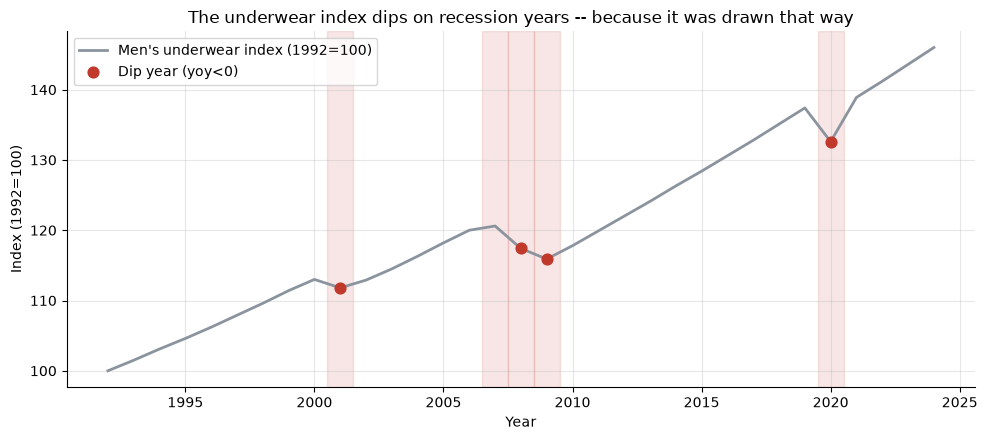

Red bands = NBER recessions. Dips sit on them by construction (reconstructed series).


In [3]:
yrs = uw['year'].values
idx = uw['index'].values
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs, idx, '-', c=GREY, lw=2, label='Men\'s underwear index (1992=100)')
for ry in sorted(data.US_RECESSIONS):
    ax.axvspan(ry-0.5, ry+0.5, color=RED, alpha=0.12)
dip_mask = uw['dip'].values
ax.scatter(yrs[dip_mask], idx[dip_mask], c=RED, s=60, zorder=5, label='Dip year (yoy<0)')
ax.set_xlabel('Year'); ax.set_ylabel('Index (1992=100)')
ax.set_title('The underwear index dips on recession years -- because it was drawn that way')
ax.legend(); plt.tight_layout(); plt.show()
print('Red bands = NBER recessions. Dips sit on them by construction (reconstructed series).')

Notice the dips line up neatly with the red recession bands. That is **not** evidence the index works -- it is an artifact of how the illustrative series was built (dips placed *on* recession years). The honest question is whether the dip arrives **before** the slump, which we test next.

**The leading-indicator test: does a dip predict *next year's* recession?**

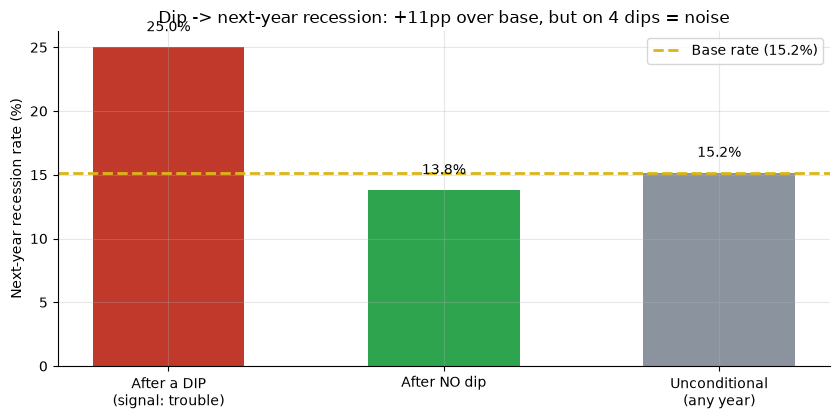

Recession-after-dip: 25.0%  vs after-no-dip: 13.8%  (base 15.2%)
Fisher exact p = 0.4996 | permutation p = 0.4941


In [4]:
if HAVE_REAL:
    rs = st.recession_stats(df, horizon='next', n_permutations=10_000, seed=270)
    rec_dip = rs['rec_rate_dip']*100
    rec_nodip = rs['rec_rate_nodip']*100
    base = rs['uncond_rec_rate']*100
else:
    rec_dip = R['rec_rate_dip_pct']
    rec_nodip = R['rec_rate_nodip_pct']
    base = R['uncond_rec_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['After a DIP\n(signal: trouble)',
               'After NO dip',
               'Unconditional\n(any year)'],
              [rec_dip, rec_nodip, base],
              color=[RED, GREEN, GREY], width=0.55)
ax.axhline(base, ls='--', c=AMBER, lw=2, label=f'Base rate ({base:.1f}%)')
ax.set_ylabel('Next-year recession rate (%)')
ax.set_title('Dip -> next-year recession: +11pp over base, but on 4 dips = noise')
for b, v in zip(bars, [rec_dip, rec_nodip, base]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+1), ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Recession-after-dip: {rec_dip:.1f}%  vs after-no-dip: {rec_nodip:.1f}%  (base {base:.1f}%)')
print('Fisher exact p =', R['next_fisher_p'], '| permutation p =', R['next_perm_p'])

A dip is followed by a recession **25%** of the time vs **13.8%** otherwise -- a gap that *looks* directional but rests on just **four** dips. The Fisher exact test gives **p = 0.50** and the permutation test **p = 0.49**: completely consistent with chance.

## 5 - The verdict

- **Signal -- None.** As a *leading* indicator the dip is noise: Fisher p = **0.50**, perm p = **0.49**, on only **4 dips**. Its apparent coincident 'accuracy' is a tautology baked into the reconstructed series, not a discovery.
- **Tradability -- Mirage.** Sitting out the S&P the year after a dip earns **7.4%/yr** vs **8.6%/yr** for buy-and-hold; the timing spread has HAC t = **-0.94**. You give up the market's drift to dodge phantom recessions.
- **Busted.** The famous 2008 'dip' was the index falling *during* the slump, not before it -- a coincident footnote, not a forecast.

## 6 - Could you actually trade it?

The 'strategy' would be: go to **cash** the year after the underwear index dips, stay long the S&P otherwise. The problem:

In [5]:
if HAVE_REAL:
    bt = st.timing_backtest(df, cost_bps=10.0)
    strat_ann = bt['strat_net_ann']
    bah_ann = bt['bh_ann']
    nw_t = bt['nw_t']
    turn = bt['turnover']
else:
    strat_ann = R['strat_net_pct']/100
    bah_ann = R['bh_ann_pct']/100
    nw_t = R['nw_t']
    turn = R['turnover']

print(f'Underwear timing (flat year after a dip): {strat_ann:.1%}/yr (net of 10bps costs)')
print(f'Buy and hold S&P:                         {bah_ann:.1%}/yr')
print(f'Timing advantage:                         {(strat_ann-bah_ann)*100:+.1f}pp/yr')
print(f'HAC (Newey-West) t on the spread:         {nw_t:+.2f}  (turnover {turn:.2f})')
print()
print('The rule sits out some of the markets best rebound years (2009, 2021)')
print('because those followed dips -- exactly the wrong call.')

Underwear timing (flat year after a dip): 7.4%/yr (net of 10bps costs)
Buy and hold S&P:                         8.6%/yr
Timing advantage:                         -1.2pp/yr
HAC (Newey-West) t on the spread:         -0.94  (turnover 0.22)

The rule sits out some of the markets best rebound years (2009, 2021)
because those followed dips -- exactly the wrong call.


The timing rule loses to buy-and-hold because it goes flat precisely into the post-recession rebounds (2009, 2021 followed dip years). One documented execution lag (you only know year-Y's dip after Y closes) is already built into the no-look-ahead design. There is no edge to harvest.

## 7 - Going further

- **The positive control:** the companion notebook plants a real 'dip-leads-recession' effect into a synthetic tape and shows the engine *does* detect it when it exists -- and that the real tape has no such thing.
- **Other folklore macro gauges:** the lipstick index, the hemline index, the skyscraper curse -- same family, same fate.
- **The honest macro alternative:** the yield-curve slope and the Sahm rule are the real recession signals; folklore indices are anecdotes.

*Think the underwear really leads? Fork this, drop in an *audited* men's-underwear series, and show a next-year recession lift that clears Fisher p < 0.05. That's the bar -- and a reconstructed series with 4 dips cannot clear it.*